In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("restaurant_data.csv")
df.head()

,Name,Location,Cuisine,Rating,Seating Capacity,Average Meal Price,Marketing Budget,Social Media Followers,Chef Experience Years,Number of Reviews,Avg Review Length,Ambience Score,Service Quality Score,Parking Availability,Weekend Reservations,Weekday Reservations,Revenue
0,Restaurant 0,Rural,Japanese,4.0,38,73.98,2224,23406,13,185,161.924906,1.3,7.0,Yes,13,4,638945.52
1,Restaurant 1,Downtown,Mexican,3.2,76,28.11,4416,42741,8,533,148.759717,2.6,3.4,Yes,48,6,490207.83
2,Restaurant 2,Rural,Italian,4.7,48,48.29,2796,37285,18,853,56.849189,5.3,6.7,No,27,14,541368.62
3,Restaurant 3,Rural,Italian,4.4,34,51.55,1167,15214,13,82,205.433265,4.6,2.8,Yes,9,17,404556.80
4,Restaurant 4,Downtown,Japanese,4.9,88,75.98,3639,40171,9,78,241.681584,8.6,2.1,No,37,26,1491046.35


In [3]:
df = df[['Location','Cuisine','Rating','Average Meal Price','Seating Capacity','Weekend Reservations','Weekday Reservations','Revenue']]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8368 entries, 0 to 8367
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Location              8368 non-null   object 
 1   Cuisine               8368 non-null   object 
 2   Rating                8368 non-null   float64
 3   Average Meal Price    8368 non-null   float64
 4   Seating Capacity      8368 non-null   int64  
 5   Weekend Reservations  8368 non-null   int64  
 6   Weekday Reservations  8368 non-null   int64  
 7   Revenue               8368 non-null   float64
dtypes: float64(3), int64(3), object(2)
memory usage: 523.1+ KB


In [4]:
df.isnull().sum()/len(df) *100

Location                0.0
Cuisine                 0.0
Rating                  0.0
Average Meal Price      0.0
Seating Capacity        0.0
Weekend Reservations    0.0
Weekday Reservations    0.0
Revenue                 0.0
dtype: float64

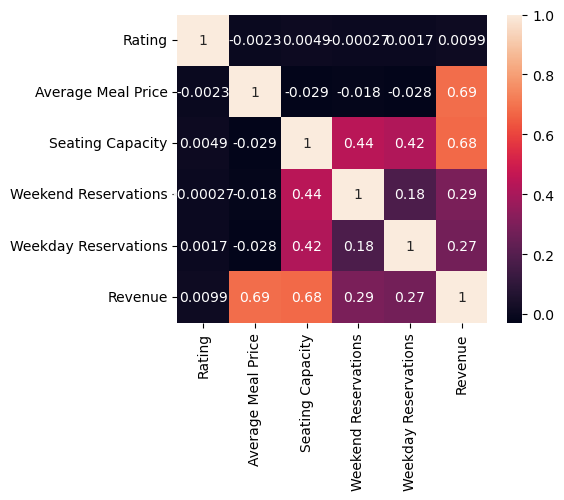

In [5]:
plt.figure(figsize=(5,4))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

In [6]:
df.describe()

,Rating,Average Meal Price,Seating Capacity,Weekend Reservations,Weekday Reservations,Revenue
count,8368.000000,8368.000000,8368.000000,8368.000000,8368.000000,8.368000e+03
mean,4.008258,47.896659,60.212835,29.491754,29.235301,6.560706e+05
std,0.581474,14.336767,17.399488,20.025415,20.004277,2.674137e+05
min,3.000000,25.000000,30.000000,0.000000,0.000000,1.847085e+05
25%,3.500000,35.490000,45.000000,13.000000,13.000000,4.546514e+05
50%,4.000000,45.535000,60.000000,27.000000,26.000000,6.042421e+05
75%,4.500000,60.300000,75.000000,43.000000,43.000000,8.130942e+05
max,5.000000,76.000000,90.000000,88.000000,88.000000,1.531868e+06


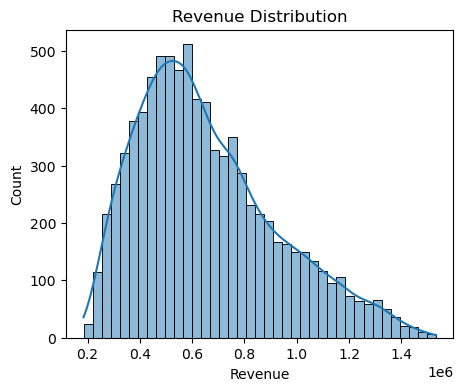

In [7]:
plt.figure(figsize=(5,4))
sns.histplot(df['Revenue'], kde=True)
plt.title("Revenue Distribution")
plt.show()

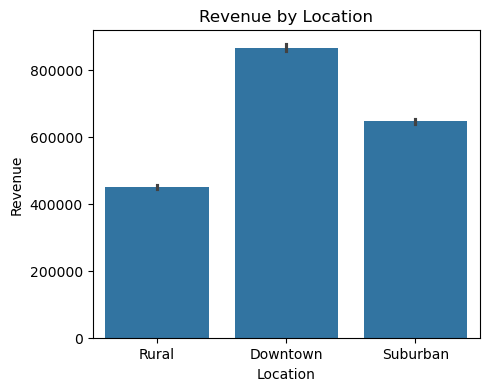

In [8]:
plt.figure(figsize=(5,4))
sns.barplot(x='Location', y='Revenue', data=df)
plt.title("Revenue by Location")
plt.show()

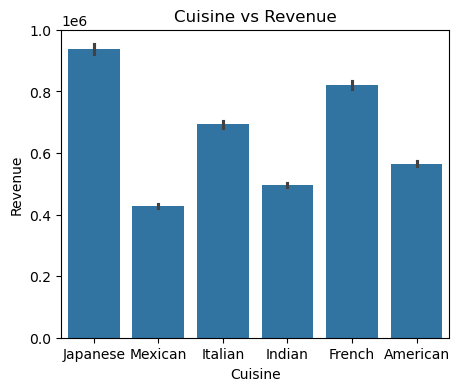

In [9]:
plt.figure(figsize=(5,4))
sns.barplot(x="Cuisine", y="Revenue", data=df)
plt.title("Cuisine vs Revenue")
plt.show()

In [10]:
x = df.drop("Revenue",axis=1)
y = df["Revenue"]

In [11]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [12]:
cat_cols = ['Location', 'Cuisine']
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), cat_cols)],remainder='passthrough')

In [13]:
x=ct.fit_transform(x)

In [14]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.20, random_state=1)

In [15]:
from sklearn.preprocessing import StandardScaler
std_scale = StandardScaler()
xtrain = std_scale.fit_transform(xtrain)
xtest = std_scale.transform(xtest)

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [17]:
lr = LinearRegression()
svm = SVR()
knn = KNeighborsRegressor()
dt = DecisionTreeRegressor()
rf = RandomForestRegressor()


In [18]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
def mymodel(model):
    model.fit(xtrain,ytrain)
    ypred = model.predict(xtest)
    print("R2_Score:", r2_score(ytest,ypred))
    print("MAE:", mean_absolute_error(ytest,ypred))
    print("MSE:", mean_squared_error(ytest,ypred))
    print("RMSE:", np.sqrt(mean_squared_error(ytest,ypred)))

    print("Training Score:", model.score(xtrain,ytrain))
    print("Testing Score:", model.score(xtest,ytest))

In [19]:
mymodel(lr)

R2_Score: 0.9577668892010074
MAE: 41589.55896298039
MSE: 2983763474.3377576
RMSE: 54623.83613714582
Training Score: 0.9574606212487183
Testing Score: 0.9577668892010074


In [20]:
mymodel(svm)

R2_Score: -0.027361351467946493
MAE: 208821.9564281556
MSE: 72582938302.74635
RMSE: 269412.2088969732
Training Score: -0.03512420259257598
Testing Score: -0.027361351467946493


In [21]:
mymodel(knn)

R2_Score: 0.9692014920412847
MAE: 35492.544661887696
MSE: 2175910354.998227
RMSE: 46646.65427443031
Training Score: 0.9803144630000961
Testing Score: 0.9692014920412847


In [22]:
mymodel(dt)

R2_Score: 0.9969201676893017
MAE: 11154.380543608126
MSE: 217589729.5248718
RMSE: 14750.923005862101
Training Score: 1.0
Testing Score: 0.9969201676893017


In [23]:
mymodel(rf)

R2_Score: 0.9990374369703334
MAE: 6634.387173894853
MSE: 68004945.77196452
RMSE: 8246.511127256454
Training Score: 0.9998604093958222
Testing Score: 0.9990374369703334


In [24]:
import pickle

pickle.dump(rf, open("model.pkl","wb"))
pickle.dump(std_scale, open("scaler.pkl","wb"))
pickle.dump(ct, open("encoder.pkl","wb"))